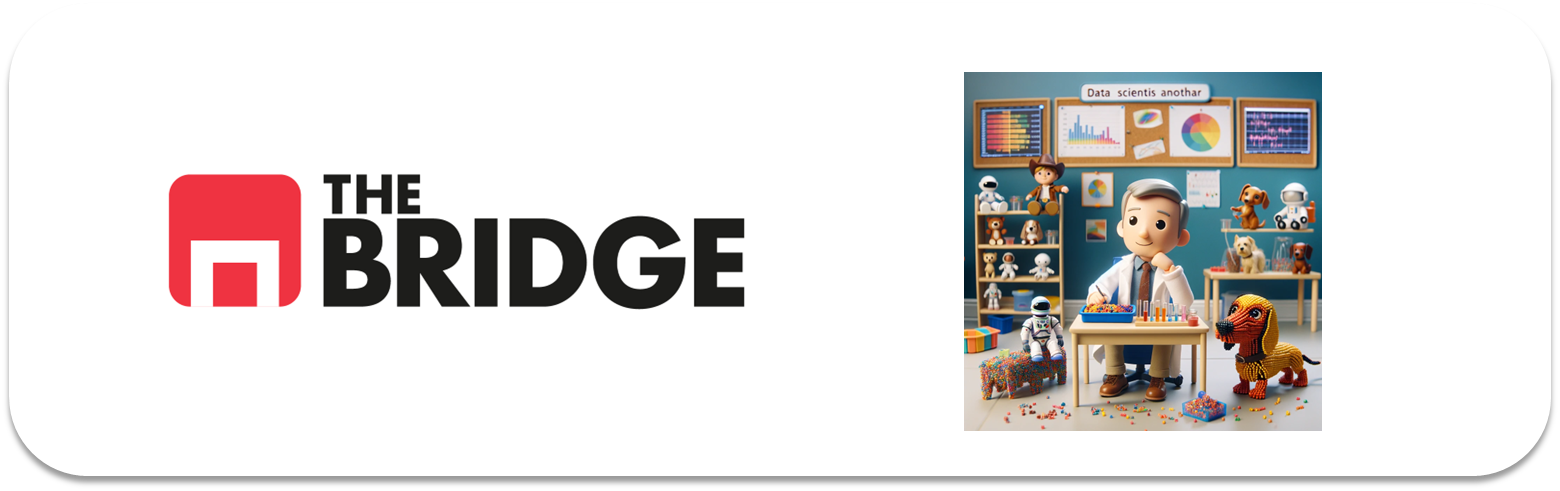

## PRACTICA OBLIGATORIA: **Análisis Univariante**

* La práctica obligatoria de esta unidad consiste en hacer el análisis univariante completo de un dataset con el que acabarás muy familiarizado, el manifiesto de pasajeros del Titanic. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook. Te dejo una que vas a necesitar sí o sí

In [1]:

import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np




### #1 Preparación


### #1.1


Carga en un dataframe los datos del titanic a partir de un dataset de seaborn. Para ello:

* ejecuta ```python sns.get_dataset_names()```
* localiza el nombre que puede ser el adecuado para el ejercicio
* Asigna la salida de ```sns.load_dataset(<nombre_del_dataset>)``` a una variable "df_titanic"

In [2]:
#datasets en seaborn
print(sns.get_dataset_names())

#dataset del Titanic
df_titanic = sns.load_dataset('titanic')
df_titanic.head()

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### #1.2

Muestra una porción del dataset ("df_titanic") y su info general. ¿Hay nulos?

In [3]:
#primeras filas
display(df_titanic.head())

#Información general
df_titanic.info()

#Nulos?
df_titanic.isnull().any()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


survived       False
pclass         False
sex            False
age             True
sibsp          False
parch          False
fare           False
embarked        True
class          False
who            False
adult_male     False
deck            True
embark_town     True
alive          False
alone          False
dtype: bool

### #1.3

Obtén el porcentaje de nulos y decide que hacer con las columnas con nulos y ejecútalo. Además deshazte de la columna "parch" que no la emplearemos.

In [4]:
null_pct = df_titanic.isnull().mean().mul(100).round(2).sort_values(ascending=False)
print(null_pct[null_pct > 0].to_string())


df_titanic.drop(columns=['deck', 'parch'], inplace=True)

median_age = df_titanic['age'].median()
df_titanic['age'] = df_titanic['age'].fillna(median_age)

df_titanic.dropna(subset=['embarked'], inplace=True)

print("Shape tras limpieza:", df_titanic.shape)
print("Nulos restantes:\n", df_titanic.isnull().sum())

deck           77.22
age            19.87
embarked        0.22
embark_town     0.22
Shape tras limpieza: (889, 13)
Nulos restantes:
 survived       0
pclass         0
sex            0
age            0
sibsp          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


### #1.4
Sobre el dataset "limpio". Rellena la tabla de descripción (muy breve) de lo que es cada columna en función de su nombre y los valores. Para ayudarte:
* Se trata del dataset que reune lo más parecido a un manifiesto de supervivientes y fallecidos en el viaje.
* sibsp: Es el numero de familiares que viajan con la persona indicada en el manifiesto (lista de pasajeros)
* embarked: Es la incial de la letra de la ciudad donde embarcó la persona.




| Columna/Variable | Descripción |
| ---------------- | ----------- |
| -       | - |



In [5]:
desc = {
    'survived':    'Supervivencia (1 = sobrevivió, 0 = falleció)',
    'pclass':      'Clase del billete (1ª, 2ª o 3ª clase)',
    'sex':         'Sexo del pasajero (male / female)',
    'age':         'Edad del pasajero en años (imputada con la mediana si era nula)',
    'sibsp':       'Número de hermanos o cónyuge a bordo',
    'fare':        'Precio del billete en libras esterlinas',
    'embarked':    'Puerto de embarque (inicial): S, C o Q',
    'class':       'Clase del billete en texto (First / Second / Third)',
    'who':         'Categoría del pasajero: man, woman o child',
    'adult_male':  'Indica si el pasajero es un hombre adulto (True/False)',
    'embark_town': 'Puerto de embarque en nombre completo',
    'alive':       'Supervivencia en texto (yes / no)',
    'alone':       'Indica si el pasajero viaja solo (True/False)',
}

df_desc = pd.DataFrame(desc.items(), columns=['Columna', 'Descripción'])
display(df_desc)

,Columna,Descripción
0,survived,"Supervivencia (1 = sobrevivió, 0 = falleció)"
1,pclass,"Clase del billete (1ª, 2ª o 3ª clase)"
2,sex,Sexo del pasajero (male / female)
3,age,Edad del pasajero en años (imputada con la med...
4,sibsp,Número de hermanos o cónyuge a bordo
5,fare,Precio del billete en libras esterlinas
6,embarked,"Puerto de embarque (inicial): S, C o Q"
7,class,Clase del billete en texto (First / Second / T...
8,who,"Categoría del pasajero: man, woman o child"
9,adult_male,Indica si el pasajero es un hombre adulto (Tru...


### #1.5

Busca en internet las tres ciudades que visitó el Titanic antes de poner rumbo a su destino y llegar a alta mar. Cambia las iniciales por esos valores.

In [6]:
#Escala en:
#   S --> Southampton (Reino Unido)
#   C --> Cherbourg (Francia)
#   Q --> Queenstown (Irlanda)

#Mapear iniciales en 'embarked'
embarked_map = {'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'}
df_titanic['embarked'] = df_titanic['embarked'].map(embarked_map)

print(df_titanic['embarked'].value_counts())

embarked
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64


### #2 Análisis

Sabiendo que el objetivo de nuestro análisis es hacer un estudio de la superviviencia y mortalidad en el viaje... Haz un análisis univariante completo y ordenado de las siguientes variables:
["survived","who","age","fare","class","embarked","alone"]
Nota: Si quieres añadir más, perfecto.

Separa el análisis en categóricas (incluyendo binarias) y numéricas. Muestra valores, gráficas y conclusiones/observaciones (2 o 3 por variable)

### #2.1 Categóricas

#### `survived` — Supervivencia (variable binaria)


Absolutos:
 survived
Fallecidos        549
Supervivientes    340
Name: count, dtype: int64

Porcentaje:
 survived
Fallecidos        61.8
Supervivientes    38.2
Name: proportion, dtype: float64


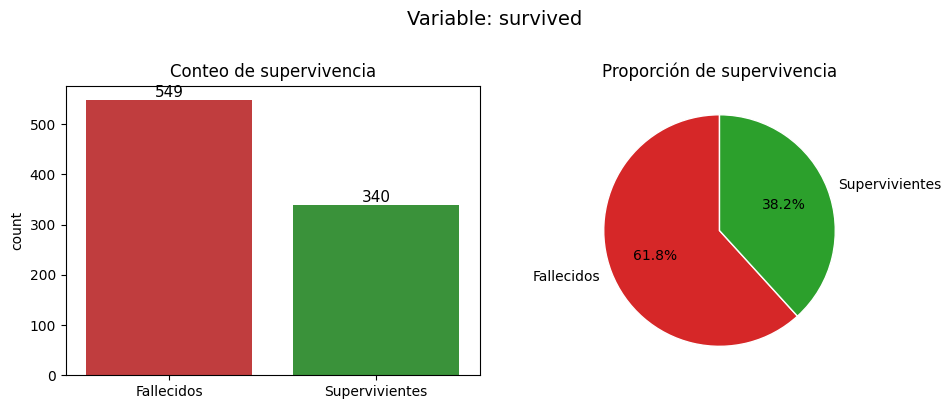

In [7]:
surv_counts = df_titanic['survived'].value_counts().rename({0: 'Fallecidos', 1: 'Supervivientes'})
surv_pct    = df_titanic['survived'].value_counts(normalize=True).mul(100).round(1).rename({0: 'Fallecidos', 1: 'Supervivientes'})

print("Absolutos:\n", surv_counts)
print("\nPorcentaje:\n", surv_pct)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(data=df_titanic, x='survived', hue='survived', legend=False,
              palette=['#d62728','#2ca02c'], order=[0, 1], ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Fallecidos', 'Supervivientes'])
axes[0].set_title('Conteo de supervivencia')
axes[0].set_xlabel('')

for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 int(bar.get_height()), ha='center', fontsize=11)

# Pie chart
axes[1].pie(surv_counts, labels=surv_counts.index,
            colors=['#d62728','#2ca02c'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Proporción de supervivencia')

plt.suptitle('Variable: survived', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observaciones:**
- Más del **60% de los pasajeros fallecieron**, lo que refleja la magnitud que tuvo esta tragedia.
- La variable está claramente **desbalanceada**, algo a tener en cuenta en modelos predictivos.
- El ratio supervivientes/fallecidos es aproximadamente 1:1.6.

#### `who` — Categoría del pasajero (man / woman / child)

Absolutos:
 who
man      537
woman    269
child     83
Name: count, dtype: int64

Porcentaje:
 who
man      60.4
woman    30.3
child     9.3
Name: proportion, dtype: float64


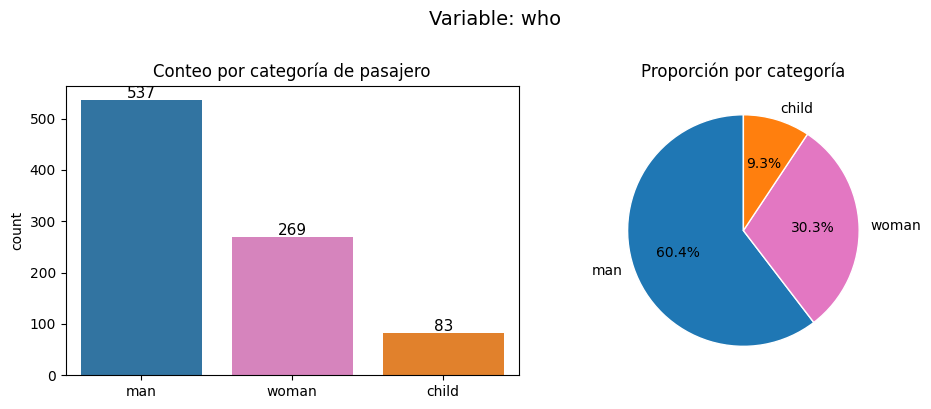

In [8]:
who_counts = df_titanic['who'].value_counts()
who_pct    = df_titanic['who'].value_counts(normalize=True).mul(100).round(1)
print("Absolutos:\n", who_counts)
print("\nPorcentaje:\n", who_pct)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

order = ['man', 'woman', 'child']
colors = ['#1f77b4', '#e377c2', '#ff7f0e']

sns.countplot(data=df_titanic, x='who', hue='who', legend=False,
              order=order, palette=colors, ax=axes[0])
axes[0].set_title('Conteo por categoría de pasajero')
axes[0].set_xlabel('')

for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 4,
                 int(bar.get_height()), ha='center', fontsize=11)

axes[1].pie(who_counts[order], labels=order, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Proporción por categoría')

plt.suptitle('Variable: who', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observaciones:**
- Los **hombres adultos** constituyen la mayoría abrumadora (~65%), lo que tiene sentido dado el perfil histórico del viaje.
- Las **mujeres** representan cerca del 27% de los pasajeros y los **niños** solo ~8%.
- Esta distribución anticipa el análisis bivariante: el protocolo "mujeres y niños primero" debería verse reflejado claramente en las tasas de supervivencia.

#### `class` — Clase del billete (First / Second / Third)

Absolutos:
 class
Third     491
First     214
Second    184
Name: count, dtype: int64

Porcentaje:
 class
Third     55.2
First     24.1
Second    20.7
Name: proportion, dtype: float64


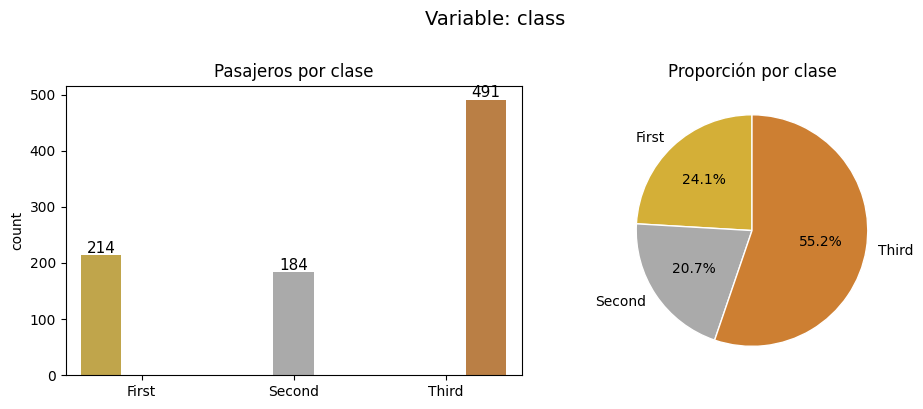

In [9]:
class_counts = df_titanic['class'].value_counts()
class_pct    = df_titanic['class'].value_counts(normalize=True).mul(100).round(1)
print("Absolutos:\n", class_counts)
print("\nPorcentaje:\n", class_pct)


order = ['First', 'Second', 'Third']
palette = ['#d4af37', '#aaaaaa', '#cd7f32']   # oro, plata, bronce

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(data=df_titanic, x='class', hue='class', legend=False,
              order=order, palette=palette, ax=axes[0])
axes[0].set_title('Pasajeros por clase')
axes[0].set_xlabel('')

for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 4,
                 int(bar.get_height()), ha='center', fontsize=11)

axes[1].pie(class_counts[order], labels=order, colors=palette,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Proporción por clase')

plt.suptitle('Variable: class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observaciones:**
- La **Tercera clase** concentra más de la mitad de los pasajeros (~55%), lo que refleja su perfil como buque de emigración transatlántica.
- La **Primera clase** supone casi un 24%, con un perfil socioeconómico muy distinto.
- La diferencia de clases será un factor clave en el análisis de supervivencia.

#### `embarked` — Puerto de embarque

Absolutos:
 embarked
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

Porcentaje:
 embarked
Southampton    72.4
Cherbourg      18.9
Queenstown      8.7
Name: proportion, dtype: float64


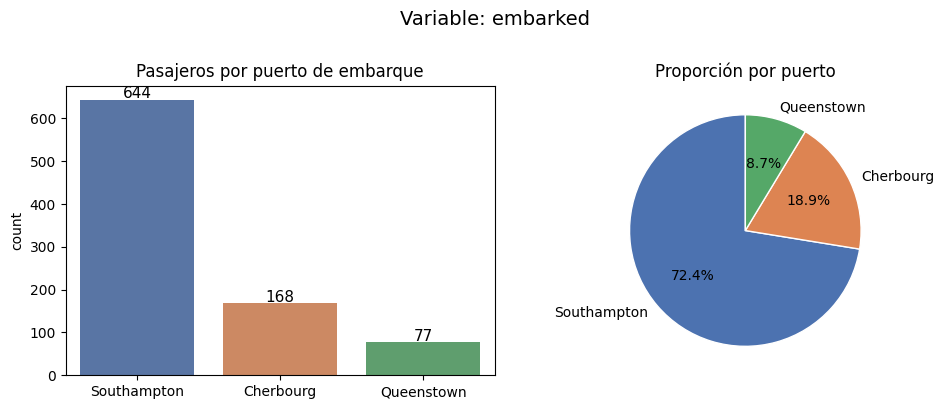

In [10]:
emb_counts = df_titanic['embarked'].value_counts()
emb_pct    = df_titanic['embarked'].value_counts(normalize=True).mul(100).round(1)
print("Absolutos:\n", emb_counts)
print("\nPorcentaje:\n", emb_pct)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

palette_emb = ['#4c72b0', '#dd8452', '#55a868']

sns.countplot(data=df_titanic, x='embarked', hue='embarked', legend=False,
              order=emb_counts.index, palette=palette_emb, ax=axes[0])
axes[0].set_title('Pasajeros por puerto de embarque')
axes[0].set_xlabel('')

for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 4,
                 int(bar.get_height()), ha='center', fontsize=11)

axes[1].pie(emb_counts, labels=emb_counts.index, colors=palette_emb,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Proporción por puerto')

plt.suptitle('Variable: embarked', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observaciones:**
- **Southampton** es el puerto principal: embarcó casi el 73% de los pasajeros, por ser el punto de salida del viaje.
- **Cherbourg** aporta aproximadamente el 19%, en su mayoría pasajeros de 1ª clase.
- **Queenstown** tuvo la menor aportación (~8%), con predominio de pasajeros de 3ª clase (emigrantes irlandeses).

#### `alone` — Viaja solo (True / False)


Absolutos:
 alone
True     535
False    354
Name: count, dtype: int64

Porcentaje:
 alone
True     60.2
False    39.8
Name: proportion, dtype: float64


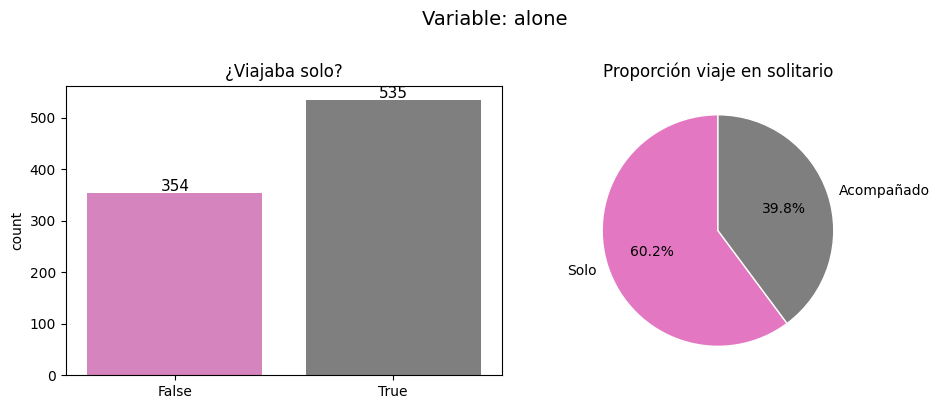

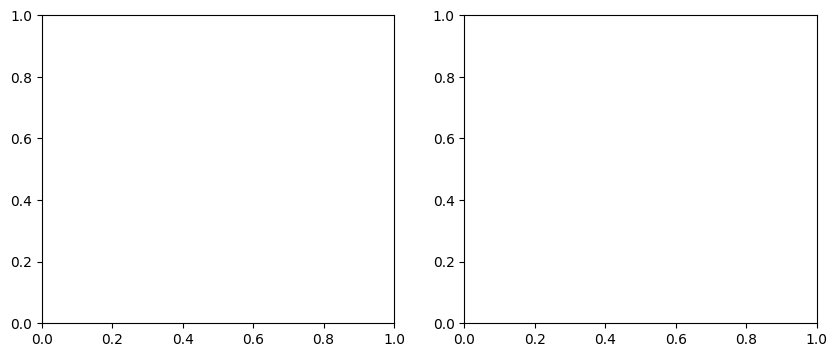

In [11]:
alone_counts = df_titanic['alone'].value_counts()
alone_pct    = df_titanic['alone'].value_counts(normalize=True).mul(100).round(1)
print("Absolutos:\n", alone_counts)
print("\nPorcentaje:\n", alone_pct)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

palette_al = ['#e377c2', '#7f7f7f']

sns.countplot(data=df_titanic, x='alone', hue='alone', legend=False,
              palette=palette_al, ax=axes[0])
axes[0].set_title('¿Viajaba solo?')
axes[0].set_xlabel('')

for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 4,
                 int(bar.get_height()), ha='center', fontsize=11)

axes[1].pie(alone_counts, labels=['Solo', 'Acompañado'], colors=palette_al,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Proporción viaje en solitario')

plt.suptitle('Variable: alone', fontsize=14, y=1.01)
plt.tight_layout()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plt.show()

**Observaciones:**
- Más del **60%** de los pasajeros viajaban solos, lo que puede reflejar el perfil emigrante de muchos pasajeros de 3ª clase.
- Viajar acompañado implica la presencia de familiares (cónyuge, hermanos), lo que podría influir en la decisión de buscar salvamento.

### #2.2 Numéricas

#### `age` — Edad del pasajero

count    889.00
mean      29.32
std       12.98
min        0.42
25%       22.00
50%       28.00
75%       35.00
max       80.00
Name: age, dtype: float64

Moda:     28.0
Varianza: 168.61
Asimetría (skewness): 0.51
Curtosis:             1.01


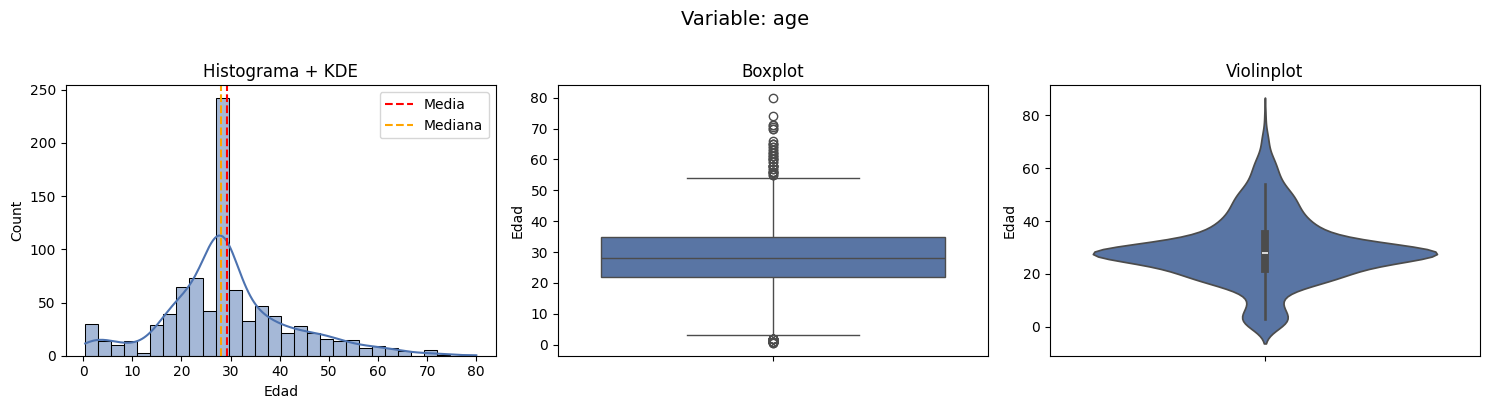

In [12]:
print(df_titanic['age'].describe().round(2))
print(f"\nModa:     {df_titanic['age'].mode()[0]}")
print(f"Varianza: {df_titanic['age'].var():.2f}")
print(f"Asimetría (skewness): {df_titanic['age'].skew():.2f}")
print(f"Curtosis:             {df_titanic['age'].kurt():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma con KDE
sns.histplot(df_titanic['age'], kde=True, bins=30,
             color='#4c72b0', ax=axes[0])
axes[0].set_title('Histograma + KDE')
axes[0].set_xlabel('Edad')
axes[0].axvline(df_titanic['age'].mean(),   color='red',    linestyle='--', label='Media')
axes[0].axvline(df_titanic['age'].median(), color='orange', linestyle='--', label='Mediana')
axes[0].legend()


sns.boxplot(y=df_titanic['age'], color='#4c72b0', ax=axes[1])
axes[1].set_title('Boxplot')
axes[1].set_ylabel('Edad')


sns.violinplot(y=df_titanic['age'], color='#4c72b0', ax=axes[2])
axes[2].set_title('Violinplot')
axes[2].set_ylabel('Edad')

plt.suptitle('Variable: age', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observaciones:**
- La distribución de edades es **ligeramente asimétrica positiva** (skewness > 0): hay una cola hacia edades más avanzadas.
- La **mediana** (alrededor de 28-30 años) es ligeramente inferior a la media, confirmando el sesgo.
- El **boxplot** muestra outliers en edades superiores a 65 años y una concentración principal entre los 20 y los 40 años, reflejo del perfil adulto y trabajador de la mayoría de pasajeros.
- La media es ~28.5 años, lo que indica un pasaje relativamente joven.

#### `fare` — Precio del billete (en £)

count    889.00
mean      32.10
std       49.70
min        0.00
25%        7.90
50%       14.45
75%       31.00
max      512.33
Name: fare, dtype: float64

Moda:     8.05
Varianza: 2469.84
Asimetría (skewness): 4.80
Curtosis:             33.51


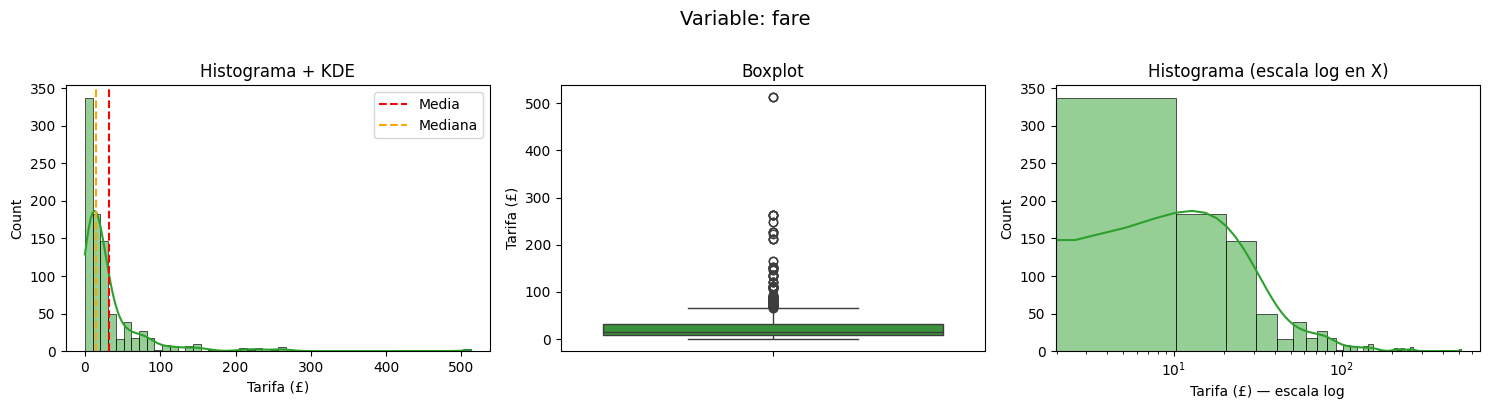

In [13]:
print(df_titanic['fare'].describe().round(2))
print(f"\nModa:     {df_titanic['fare'].mode()[0]}")
print(f"Varianza: {df_titanic['fare'].var():.2f}")
print(f"Asimetría (skewness): {df_titanic['fare'].skew():.2f}")
print(f"Curtosis:             {df_titanic['fare'].kurt():.2f}")


fig, axes = plt.subplots(1, 3, figsize=(15, 4))


sns.histplot(df_titanic['fare'], kde=True, bins=50,
             color='#2ca02c', ax=axes[0])
axes[0].set_title('Histograma + KDE')
axes[0].set_xlabel('Tarifa (£)')
axes[0].axvline(df_titanic['fare'].mean(),   color='red',    linestyle='--', label='Media')
axes[0].axvline(df_titanic['fare'].median(), color='orange', linestyle='--', label='Mediana')
axes[0].legend()


sns.boxplot(y=df_titanic['fare'], color='#2ca02c', ax=axes[1])
axes[1].set_title('Boxplot')
axes[1].set_ylabel('Tarifa (£)')


sns.histplot(df_titanic['fare'], kde=True, bins=50,
             color='#2ca02c', ax=axes[2], log_scale=(False, False))
axes[2].set_xscale('log')
axes[2].set_title('Histograma (escala log en X)')
axes[2].set_xlabel('Tarifa (£) — escala log')

plt.suptitle('Variable: fare', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observaciones:**
- `fare` presenta una **fuerte asimetría positiva** (skewness >> 1): la mayoría de pasajeros pagó tarifas bajas, pero algunos billetes de primera clase alcanzaron valores muy elevados (outliers extremos).
- La **mediana** (~14 £) es mucho más representativa que la **media** (~32 £), que está inflada por esos valores extremos.
- En escala logarítmica se aprecian mejor las tres "modas" que corresponden aproximadamente a las tres clases del barco.
- Esta variable es un buen proxy de la clase socioeconómica del pasajero.

## Resumen del Análisis Univariante

| Variable    | Tipo        | Hallazgo principal                                               |
|-------------|-------------|------------------------------------------------------------------|
| `survived`  | Binaria     | 60% fallecidos vs 40% supervivientes — dataset desbalanceado     |
| `who`       | Categórica  | 65% hombres adultos, 27% mujeres, 8% niños                       |
| `class`     | Categórica  | 55% tercera clase, 24% primera, 21% segunda                      |
| `embarked`  | Categórica  | 73% embarcaron en Southampton                                    |
| `alone`     | Binaria     | 62% viajaba solo                                                 |
| `age`       | Numérica    | Distribución asimétrica (+), media ~29 años, outliers en mayores |
| `fare`      | Numérica    | Muy asimétrica (+), mediana ~14£, media inflada por outliers     |

> El siguiente paso natural sería el **análisis bivariante**, cruzando cada una de estas variables con `survived` para identificar los factores asociados a la supervivencia.